# Stroke Prediction — Data Preprocessing

**Dataset:** [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) (Kaggle, fedesoriano)

Tarefa 4 da APS1. Usa o split treino/teste do notebook 01 e aplica as decisões da análise exploratória.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import MissingIndicator, SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False,
                                     "axes.titleweight": "bold", "legend.frameon": False, "figure.dpi": 110})

AZUL, LARANJA, VIOLETA = "#2a78d6", "#eb6834", "#4a3aa7"
PALETA_AVC = {"Sem AVC": AZUL, "Com AVC": LARANJA}

TARGET = "stroke"
NUM_COLS = ["age", "avg_glucose_level", "bmi"]
BIN_COLS = ["hypertension", "heart_disease"]
CAT_COLS = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

## Carregamento

Lê o split salvo pelo notebook 01. Se ele não existir, refaz o mesmo split a partir do Kaggle.

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"

if (PROCESSED / "train.csv").exists():
    train, test = pd.read_csv(PROCESSED / "train.csv"), pd.read_csv(PROCESSED / "test.csv")
else:
    import kagglehub
    from sklearn.model_selection import train_test_split
    df = pd.read_csv(Path(kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")) / "healthcare-dataset-stroke-data.csv")
    df = df.drop(columns="id").query("gender != 'Other'")
    train, test = train_test_split(df, test_size=0.2, stratify=df[TARGET], random_state=42)
    PROCESSED.mkdir(parents=True, exist_ok=True)

X_train, y_train = train.drop(columns=TARGET), train[TARGET]
X_test, y_test = test.drop(columns=TARGET), test[TARGET]
print(f"treino {X_train.shape}, teste {X_test.shape}, AVC no treino {y_train.mean():.1%}")

treino (4087, 10), teste (1022, 10), AVC no treino 4.9%


# Tarefa 4 — Pré-processamento para modelagem

### 4.1 Valores ausentes

In [3]:
mediana = X_train["bmi"].median()
print(f"IMC ausente: {X_train['bmi'].isna().sum()} no treino, {X_test['bmi'].isna().sum()} no teste")
print(f"Desvio padrão do IMC: {X_train['bmi'].std():.2f} antes e {X_train['bmi'].fillna(mediana).std():.2f} depois de imputar a mediana ({mediana})")
print(f"Tabagismo desconhecido: {X_train['smoking_status'].eq('Unknown').mean():.1%} do treino")

IMC ausente: 163 no treino, 38 no teste
Desvio padrão do IMC: 7.90 antes e 7.74 depois de imputar a mediana (28.1)
Tabagismo desconhecido: 30.2% do treino


O IMC é a única coluna com nulos: 163 no treino e 38 no teste. Como a ausência está ligada ao AVC (19,9% de AVC entre quem não tem IMC), as linhas ficam: o valor é imputado pela mediana do treino, mais robusta à cauda direita do que a média, e uma coluna indicadora registra que estava ausente. A imputação quase não altera a distribuição (desvio padrão de 7,90 para 7,74). O tabagismo desconhecido vira categoria própria, porque concentra as crianças e por isso carrega informação.

### 4.2 Outliers

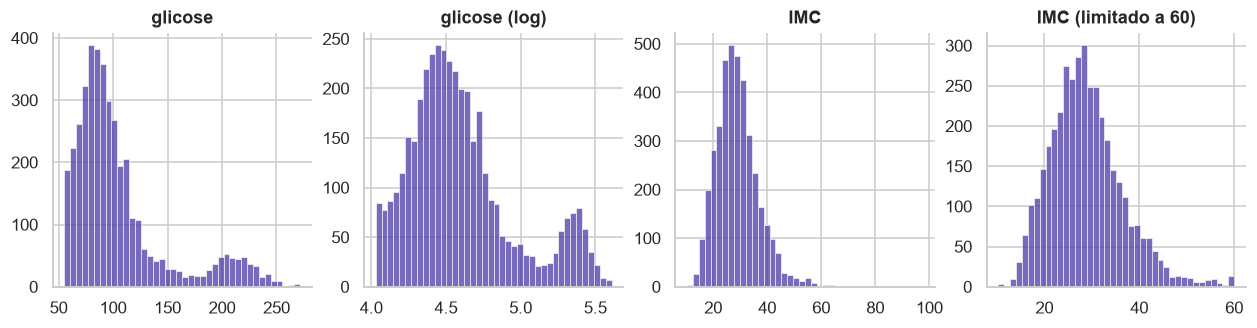

,assimetria,máximo
glicose,1.58,271.74
glicose (log),0.89,5.61
IMC,1.12,97.60
IMC (limitado a 60),0.80,60.00


In [4]:
tratadas = pd.DataFrame({"glicose": X_train["avg_glucose_level"], "glicose (log)": np.log1p(X_train["avg_glucose_level"]),
                         "IMC": X_train["bmi"], "IMC (limitado a 60)": X_train["bmi"].clip(upper=60)})

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, col in zip(axes, tratadas):
    sns.histplot(tratadas[col], bins=40, ax=ax, color=VIOLETA).set(title=col, xlabel="", ylabel="")
plt.show()

tratadas.agg(["skew", "max"]).T.rename(columns={"skew": "assimetria", "max": "máximo"}).round(2)

Os outliers de glicose formam o grupo com glicemia alta, que tem o triplo da taxa de AVC, então são mantidos: o logaritmo reduz a assimetria de 1,58 para 0,89 sem apagar o segundo pico. No IMC, valores acima de 60 são implausíveis e são limitados a 60, o que reduz a assimetria de 1,12 para 0,80 sem descartar pacientes. A idade não tem outliers. As duas transformações são funções fixas, então não dependem do teste.

### 4.3 Encoding das variáveis categóricas

In [5]:
nomes = OneHotEncoder(drop="if_binary").fit(X_train[CAT_COLS]).get_feature_names_out()
print(f"{len(nomes)} colunas:", ", ".join(nomes))
print("Categorias do teste que não existem no treino:", sum(len(set(X_test[c]) - set(X_train[c])) for c in CAT_COLS))

12 colunas: gender_Male, ever_married_Yes, work_type_Govt_job, work_type_Never_worked, work_type_Private, work_type_Self-employed, work_type_children, Residence_type_Urban, smoking_status_Unknown, smoking_status_formerly smoked, smoking_status_never smoked, smoking_status_smokes
Categorias do teste que não existem no treino: 0


As categóricas são nominais e têm poucas categorias, então recebem one-hot encoding: 12 colunas. As de duas categorias (gênero, estado civil, residência) viram uma única coluna 0/1. Quem nunca trabalhou fica como categoria própria mesmo com 16 pacientes. Todas as categorias do teste existem no treino; ainda assim, o encoder do pipeline ignora categorias novas em vez de falhar.

### 4.4 Padronização das variáveis numéricas

In [6]:
escalas = X_train[NUM_COLS].agg(["min", "max", "std"]).T
escalas["% abaixo da metade da escala"] = [(X_train[c] < (escalas.loc[c, "min"] + escalas.loc[c, "max"]) / 2).mean() * 100 for c in NUM_COLS]
escalas.round(1)

,min,max,std,% abaixo da metade da escala
age,0.1,82.0,22.6,45.3
avg_glucose_level,55.2,271.7,44.7,87.6
bmi,10.3,97.6,7.9,95.1


Idade, glicose e IMC têm escalas diferentes, e regressão logística, KNN e SVM são sensíveis a isso. A padronização (média 0, desvio 1) foi escolhida no lugar do Min-Max porque este usa o máximo como referência: 88% dos pacientes ficariam na metade inferior da escala da glicose, e 95% na do IMC. As binárias e as colunas do one-hot já estão em 0/1 e não são escaladas. Médias e desvios são calculados só no treino.

### 4.5 Redução de dimensionalidade (PCA)

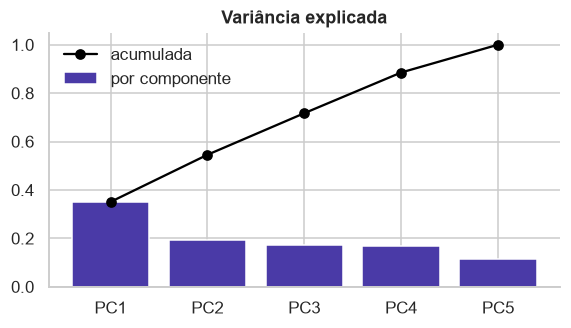

In [7]:
X_num = X_train[NUM_COLS + BIN_COLS].assign(avg_glucose_level=tratadas["glicose (log)"], bmi=tratadas["IMC (limitado a 60)"])
pca = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), PCA())
componentes = pca.fit_transform(X_num)

variancia = pca[-1].explained_variance_ratio_
nomes_pc = [f"PC{i + 1}" for i in range(len(variancia))]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(nomes_pc, variancia, color=VIOLETA, label="por componente")
ax.plot(nomes_pc, variancia.cumsum(), color="black", marker="o", label="acumulada")
ax.set(title="Variância explicada", ylim=(0, 1.05))
ax.legend()
plt.show()

O PCA usa as três contínuas (glicose com log, IMC limitado e imputado) e as duas binárias, padronizadas. As duas primeiras componentes explicam 55% da variância e são necessárias quatro para chegar a 88%: as variáveis são pouco correlacionadas, então há pouca redundância a comprimir. O PCA serve para visualizar a estrutura dos dados, não para reduzir features na modelagem.

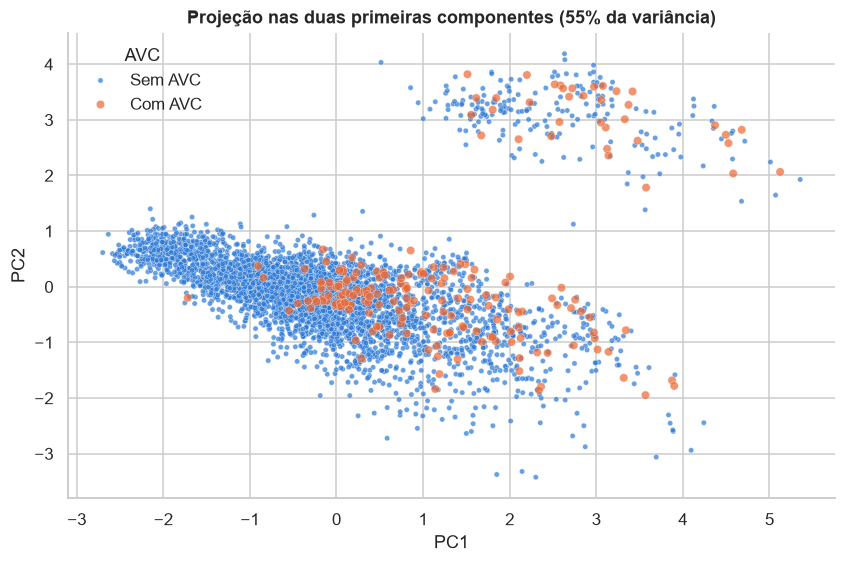

,pacientes,taxa_avc
PC1,,
até -1,917,0.1
-1 a 0,1346,1.7
0 a 1,995,6.6
1 a 2,490,10.0
acima de 2,339,17.7


In [8]:
projecao = pd.DataFrame(componentes[:, :2], columns=["PC1", "PC2"], index=X_train.index)
projecao["AVC"] = y_train.map({0: "Sem AVC", 1: "Com AVC"})

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=projecao.sort_values("AVC", ascending=False), x="PC1", y="PC2", hue="AVC", palette=PALETA_AVC,
                size="AVC", sizes={"Sem AVC": 12, "Com AVC": 30}, alpha=0.7, ax=ax)
ax.set(title=f"Projeção nas duas primeiras componentes ({variancia[:2].sum():.0%} da variância)")
plt.show()

faixa_pc1 = pd.cut(projecao["PC1"], [-10, -1, 0, 1, 2, 10], labels=["até -1", "-1 a 0", "0 a 1", "1 a 2", "acima de 2"])
projecao.groupby(faixa_pc1, observed=True)["AVC"].agg(pacientes="size", taxa_avc=lambda s: round(s.eq("Com AVC").mean() * 100, 1))

A primeira componente separa parcialmente as classes: a taxa de AVC cresce de 0,1% na faixa mais baixa de PC1 para 17,7% acima de 2. Mas a sobreposição é grande: quase metade dos casos de AVC está na mesma região da maioria dos pacientes sem AVC, e não há agrupamento só de AVC. O grupo isolado no alto do gráfico são os pacientes com doença cardíaca, separados pela segunda componente.

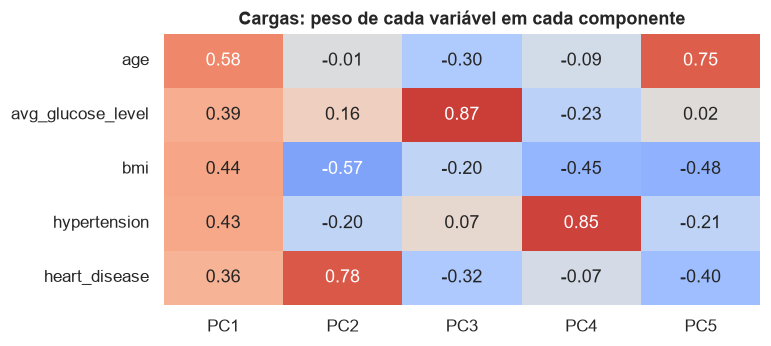

In [9]:
cargas = pd.DataFrame(pca[-1].components_.T, index=X_num.columns, columns=nomes_pc)

fig, ax = plt.subplots(figsize=(7, 3.2))
sns.heatmap(cargas, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, cbar=False, ax=ax)
ax.set(title="Cargas: peso de cada variável em cada componente")
plt.show()

A primeira componente tem pesos positivos em todas as variáveis, com destaque para a idade: é um eixo de risco geral, que cresce com idade, glicose, IMC, hipertensão e doença cardíaca. A segunda opõe doença cardíaca a IMC, a terceira é quase só glicose e a quarta quase só hipertensão. A idade é a variável mais informativa, e as demais carregam informação própria, não redundante.

### 4.6 Pipeline de pré-processamento

In [10]:
log = FunctionTransformer(np.log1p, feature_names_out="one-to-one")
limitar = FunctionTransformer(np.clip, kw_args={"a_min": None, "a_max": 60}, feature_names_out="one-to-one")

preprocessador = ColumnTransformer([
    ("idade", StandardScaler(), ["age"]),
    ("glicose", make_pipeline(log, StandardScaler()), ["avg_glucose_level"]),
    ("imc", make_pipeline(limitar, SimpleImputer(strategy="median"), StandardScaler()), ["bmi"]),
    ("imc_ausente", MissingIndicator(), ["bmi"]),
    ("binarias", "passthrough", BIN_COLS),
    ("categoricas", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False), CAT_COLS),
], verbose_feature_names_out=False).set_output(transform="pandas")

X_train_prep = preprocessador.fit_transform(X_train).astype({"missingindicator_bmi": int})
X_test_prep = preprocessador.transform(X_test).astype({"missingindicator_bmi": int})
X_train_prep.assign(stroke=y_train).to_csv(PROCESSED / "train_processed.csv", index=False)
X_test_prep.assign(stroke=y_test).to_csv(PROCESSED / "test_processed.csv", index=False)

print(f"treino {X_train_prep.shape}, teste {X_test_prep.shape}, nulos: {X_train_prep.isna().sum().sum() + X_test_prep.isna().sum().sum()}")
X_train_prep.describe().T[["mean", "std", "min", "max"]].round(2)

treino (4087, 18), teste (1022, 18), nulos: 0


,mean,std,min,max
age,-0.00,1.00,-1.91,1.71
avg_glucose_level,-0.00,1.00,-1.61,2.84
bmi,-0.00,1.00,-2.45,4.12
missingindicator_bmi,0.04,0.20,0.00,1.00
hypertension,0.09,0.29,0.00,1.00
heart_disease,0.06,0.23,0.00,1.00
gender_Male,0.41,0.49,0.00,1.00
ever_married_Yes,0.66,0.47,0.00,1.00
work_type_Govt_job,0.13,0.34,0.00,1.00
work_type_Never_worked,0.00,0.06,0.00,1.00


In [11]:
preprocessador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('idade', ...), ('glicose', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per trans

O pipeline aplica cada tratamento à sua coluna e devolve 18 features sem valores ausentes, com as contínuas em média 0 e desvio 1. É ajustado só no treino e aplicado ao teste. Os conjuntos transformados ficam salvos em data/processed (train_processed.csv e test_processed.csv), com o target na última coluna. Na APS2, o pipeline pode ser encadeado com um classificador, para que o pré-processamento seja refeito dentro de cada dobra da validação cruzada.